
# Classification
## k-NN

# Ko'krak saratonini aniqlash

**Tavsif:**
Ko'krak saratoni dunyodagi ayollar orasida eng keng tarqalgan saraton hisoblanadi. Bu barcha saraton holatlarining 25 foizini tashkil qiladi. Ko'krark saratoni ko'krakdagi hujayralar nazoratsiz o'sishidan boshlanadi. Ushbu hujayralar odatda rentgen nurlari orqali ko'rish mumkin bo'lgan o'simtalarni tahlil qilish orqali aniqlanadi.

**Ushbu ma'lumotlar to'plami Kaggle'dan olingan.**

    Bu ustunlar ro'yxati tibbiy ma'lumotlar to'plamiga (ko'pincha mashhur Wisconsin Breast Cancer Dataset) tegishli bo'lib, ko'krak saratoni tashxisini qo'yishda ishlatiladigan belgilardir. Bu yerda har bir xususiyat yadro (hujayra markazi) tasvirlaridan olingan.

    Keling, ularni mantiqiy guruhlarga bo'lib ko'rib chiqamiz:
   ####  1. Umumiy ma'lumotlar
- `id:` Bemorning identifikatsiya raqami.
- `diagnosis:` Tashxis (M = malignant/yomon sifatli o'sma, B = benign/yaxshi sifatli o'sma). Bu bizning target (maqsadli) o'zgaruvchimiz.
  #### 2. Hujayra o'lchovlari (Asosiy xususiyatlar)
  Bu yerda har bir termin uchun uch xil ko'rsatkich bor: `mean (o'rtacha), se (standard error - xatolik)` va `worst (eng yomon/katta qiymat)`.
  - radius: Markazdan chekkagacha bo'lgan masofalar o'rtachasi.
  - texture: Kulrang tuslar darajasining standart og'ishi (tasvirning g'adir-budurligi).
  - perimeter: Hujayra yadrosining aylana uzunligi.
  - area: Hujayra yadrosining yuzasi.
  - smoothness: Radius uzunliklarining mahalliy o'zgaruvchanligi (silliqlik darajasi).
  - compactness: G'ovaklik darajasi ($perimeter^2 / area - 1.0$).
  - concavity: Konturning (chegaraning) botiq qismlarining og'irligi.
  - concave points: Konturning botiq qismlari soni.
  - symmetry: Hujayraning simmetrikligi.
  - fractal_dimension: "Chegara chizig'ining murakkabligi" (fraktal o'lchami).
    #### 3. Qo'shimchalar (Suffixes)
    Har bir xususiyat 3 xil ko'rinishda takrorlanadi:
    - _mean (O'rtacha): Barcha hujayralardan olingan o'rtacha qiymat.
    - _se (Standard Error): O'lchovlardagi xatolik yoki o'zgaruvchanlik darajasi.
    - _worst (Eng yomoni): Eng katta yoki eng xavfli deb topilgan hujayraning qiymati (odatda 3 ta eng katta qiymatning o'rtachasi).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn 


In [2]:
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/breast-cancer.csv"
df = pd.read_csv(url)
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
504,915186,B,9.268,12.87,61.49,248.7,0.16340,0.22390,0.097300,0.05252,...,10.280,16.38,69.05,300.2,0.19020,0.34410,0.20990,0.10250,0.3038,0.12520
424,907145,B,9.742,19.12,61.93,289.7,0.10750,0.08333,0.008934,0.01967,...,11.210,23.17,71.79,380.9,0.13980,0.13520,0.02085,0.04589,0.3196,0.08009
538,921092,B,7.729,25.49,47.98,178.8,0.08098,0.04878,0.000000,0.00000,...,9.077,30.92,57.17,248.0,0.12560,0.08340,0.00000,0.00000,0.3058,0.09938
473,9113846,B,12.270,29.97,77.42,465.4,0.07699,0.03398,0.000000,0.00000,...,13.450,38.05,85.08,558.9,0.09422,0.05213,0.00000,0.00000,0.2409,0.06743
10,845636,M,16.020,23.24,102.70,797.8,0.08206,0.06669,0.032990,0.03323,...,19.190,33.88,123.80,1150.0,0.11810,0.15510,0.14590,0.09975,0.2948,0.08452
49,857156,B,13.490,22.30,86.91,561.0,0.08752,0.07698,0.047510,0.03384,...,15.150,31.82,99.00,698.8,0.11620,0.17110,0.22820,0.12820,0.2871,0.06917
227,88147102,B,15.000,15.51,97.45,684.5,0.08371,0.10960,0.065050,0.03780,...,16.410,19.31,114.20,808.2,0.11360,0.36270,0.34020,0.13790,0.2954,0.08362
14,84667401,M,13.730,22.61,93.60,578.3,0.11310,0.22930,0.212800,0.08025,...,15.030,32.01,108.80,697.7,0.16510,0.77250,0.69430,0.22080,0.3596,0.14310
281,8912055,B,11.740,14.02,74.24,427.3,0.07813,0.04340,0.022450,0.02763,...,13.310,18.26,84.70,533.7,0.10360,0.08500,0.06735,0.08290,0.3101,0.06688
6,844359,M,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.112700,0.07400,...,22.880,27.66,153.20,1606.0,0.14420,0.25760,0.37840,0.19320,0.3063,0.08368


In [31]:
df = pd.read_csv('kokrak_saratoni.csv', index_col = 0)
df.sample(10)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
269,8910720,0,10.710,20.39,69.50,344.9,0.10820,0.12890,0.08448,0.028670,...,11.69,25.21,76.51,410.4,0.1335,0.25500,0.25340,0.08600,0.2605,0.08701
376,901315,0,10.570,20.22,70.15,338.3,0.09073,0.16600,0.22800,0.059410,...,10.85,22.82,76.51,351.9,0.1143,0.36190,0.60300,0.14650,0.2597,0.12000
140,868999,0,9.738,11.97,61.24,288.5,0.09250,0.04102,0.00000,0.000000,...,10.62,14.10,66.53,342.9,0.1234,0.07204,0.00000,0.00000,0.3105,0.08151
131,8670,1,15.460,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.080870,...,19.26,26.00,124.90,1156.0,0.1546,0.23940,0.37910,0.15140,0.2837,0.08019
220,8812816,0,13.650,13.16,87.88,568.9,0.09646,0.08711,0.03888,0.025630,...,15.34,16.35,99.71,706.2,0.1311,0.24740,0.17590,0.08056,0.2380,0.08718
351,899667,1,15.750,19.22,107.10,758.6,0.12430,0.23640,0.29140,0.124200,...,17.36,24.17,119.40,915.3,0.1550,0.50460,0.68720,0.21350,0.4245,0.10500
244,884180,1,19.400,23.50,129.10,1155.0,0.10270,0.15580,0.20490,0.088860,...,21.65,30.53,144.90,1417.0,0.1463,0.29680,0.34580,0.15640,0.2920,0.07614
316,894090,0,12.180,14.08,77.25,461.4,0.07734,0.03212,0.01123,0.005051,...,12.85,16.47,81.60,513.1,0.1001,0.05332,0.04116,0.01852,0.2293,0.06037
216,8811523,0,11.890,18.35,77.32,432.2,0.09363,0.11540,0.06636,0.031420,...,13.25,27.10,86.20,531.2,0.1405,0.30460,0.28060,0.11380,0.3397,0.08365
103,862980,0,9.876,19.40,63.95,298.3,0.10050,0.09697,0.06154,0.030290,...,10.76,26.83,72.22,361.2,0.1559,0.23020,0.26440,0.09749,0.2622,0.08490


In [32]:
df.shape

(569, 32)

Dataset ko'krakdagi o'simta haqida ma'lumotlarni jamlagan. `diagnosis` ustuni esa o'simta rak (M - malignant) yoki rak emas (B - benign) anglatadi.

Keling bu qiymatlarni 0 va 1 ga o'zgartiramiz. M->1, B->0

Buning uchun yoki `sklearn` tarkibidagi `LabelEncoder` dan yoki `pandas` dagi `.replace()` metodidan foydalanish mumkin. Biz ikkisini ham qoldiramiz.

In [34]:
df['diagnosis'] = df['diagnosis'].replace('M', 1)
df['diagnosis'] = df['diagnosis'].replace('B', 0)
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [35]:
df['diagnosis'] = df['diagnosis'].replace( { 'M': 1, 'B': 0 } )
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

ID ustunini tashplab yuborman

In [36]:
df.drop(columns = ['id'], inplace = True)


Butun datasetdagi korrelatsiyani ( ya`ni chiziqli bogliqlikni aniqlayman) 
coolwarm palitrasida ranglar quyidagicha ma'no beradi:
- To'q Qizil (Dark Red): $+1$ ga yaqin kuchli ijobiy korrelyatsiya.
- To'q Ko'k (Dark Blue): $-1$ ga yaqin kuchli salbiy korrelyatsiya.
- Och/Oq ranglar: $0$ ga yaqin, ya'ni bog'liqlik yo'q.

In [37]:
corr_matrix = df.corr().abs()
corr_matrix.style.background_gradient(cmap = 'coolwarm')

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,0.012838,0.567134,0.008303,0.556141,0.548236,0.067016,0.292999,0.253730,0.408042,0.006522,0.077972,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,0.679090,0.097317,0.674172,0.735864,0.222600,0.206000,0.194204,0.376169,0.104321,0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,0.071401,0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,0.691765,0.086761,0.693135,0.744983,0.202694,0.250744,0.228082,0.407217,0.081629,0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.283110,0.732562,0.066280,0.726628,0.800086,0.166777,0.212583,0.207660,0.372320,0.072497,0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


In [38]:
df.corrwith(df['diagnosis']).abs().sort_values(ascending = False) 

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se              0

### ML tayyorgarlik

In [39]:
x = df.drop('diagnosis',  axis = 1).values
y = df['diagnosis']

In [40]:
# train/test split 

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,  test_size= 0.2, random_state = 12)

In [41]:
# Normalizatsiya

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaler.fit(x_train)

StandardScaler()

In [42]:
# transform 

x_train_scaler = scaler.transform(x_train)
x_test_scaler = scaler.transform(x_test)



#### ML k- NN modelni qurish



In [43]:
from  sklearn.neighbors  import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5 )
knn.fit(x_train_scaler, y_train )

KNeighborsClassifier()

#### Bashorat qilish

In [44]:
y_predict = knn.predict(x_test_scaler)

### Baholash 
#### Jaccard index

In [45]:
from sklearn.metrics import jaccard_score

# pos_label=1 bu yerda 'Malignant' (xavfli) klassi uchun hisoblashni bildiradi
jaccard = jaccard_score(y_test, y_predict, pos_label=1)
print(f"Jaccard Index: {jaccard}")

Jaccard Index: 0.8958333333333334


### Confusion matrix

Confusion Matrix (Asos)
Bu matritsa modelning qayerda adashganini va qayerda to'g'ri topganini ko'rsatuvchi xaritadir.

  - TP (True Positive): Kasalni "Kasal" deb to'g'ri topdi.

  - TN (True Negative): Sog'lomni "Sog'lom" deb to'g'ri topdi.
  - FP (False Positive): Sog'lomni "Kasal" deb xato aytdi (1-tur xatosi).

 - FN (False Negative): Kasalni "Sog'lom" deb xato aytdi (2-tur xatosi - Tibbiyotda eng xavflisi!).

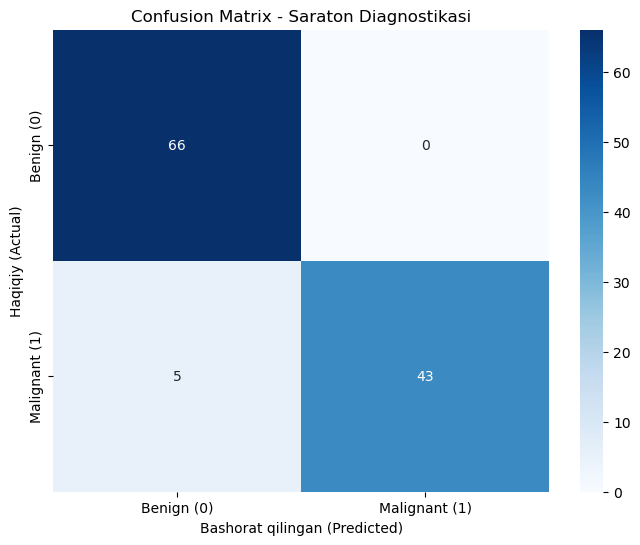

In [47]:
# Confusion Matrix vizualizatsiyasi
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_predict)

# Heatmap chizamiz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'])

plt.xlabel('Bashorat qilingan (Predicted)')
plt.ylabel('Haqiqiy (Actual)')
plt.title('Confusion Matrix - Saraton Diagnostikasi')
plt.show()

### Precision, recall, F1

 Precision va Recall (Sifat va Qamrov)Bular ko'pincha bir-biriga qarshi ishlaydigan tushunchalardir:Precision (Aniqlik): Model "Kasal" deb aytganlarning necha foizi haqiqatda kasal?Mantiq: "Agar model kasal desa, unga qanchalik ishonsa bo'ladi?"Formula: $Precision = \frac{TP}{TP + FP}$

 Recall (Sezgirlik): Haqiqatda kasal bo'lganlarning necha foizini modelimiz topa oldi?Mantiq: "Model biron bir kasalni o'tkazib yubormadimi?"Formula: $Recall = \frac{TP}{TP + FN}$

 `F1 Score (Oltin o'rtalik)
Precision va Recall o'rtasidagi muvozanat. Agar biri juda baland, ikkinchisi juda past bo'lsa (masalan, hamma bemorni "kasal" deb aytsak, Recall 100% bo'ladi, lekin Precision tushib ketadi), F1-score past chiqadi.`

Jaccard Index (O'xshashlik koeffitsiyenti)Bu ko'rsatkich model bashorat qilgan to'plam va haqiqiy natijalar to'plami bir-biriga necha foiz mos kelishini o'lchaydi.0 dan 1 gacha o'lchanadi. 1 — mukammal moslik.Formula: $J = \frac{|Y_{haqiqiy} \cap Y_{bashorat}|}{|Y_{haqiqiy} \cup Y_{bashorat}|}$

  - Mantiqiy misol bilan tushunish:
Tasavvur qiling, 10 ta bemor bor. 5 tasi haqiqatda kasal.

Model hamma 10 kishini "Kasal" deb aytdi.

Recall: 100% (Chunki birorta ham kasalni o'tkazib yubormadi).

Precision: 50% (Chunki aytganlarining yarmi sog'lom edi).

Model faqat 1 kishini "Kasal" dedi va u rostdan ham kasal.

Precision: 100% (Chunki nishonni aniq urdi).

Recall: 20% (Chunki qolgan 4 ta kasalni topa olmadi).

Sizning saraton loyihangizda: Bizga Recall muhimroq. Chunki saraton bor bemorni "sog'lom" (FN) deb chiqarib yuborish o'limga olib kelishi mumkin. Sog'lom odamni "kasal" (FP) deb aytish esa qo'shimcha tekshiruv bilan hal bo'la

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score 
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
accuracy = accuracy_score(y_test, y_predict)
print(f"{precision = }\n{recall = }\n{f1 = }\n{accuracy = } ")

precision = 1.0
recall = 0.8958333333333334
f1 = 0.945054945054945
accuracy = 0.956140350877193 


In [49]:
from sklearn.metrics import classification_report 
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        66
           1       1.00      0.90      0.95        48

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Eng yaxshi k ni topish

### `for` yordamida

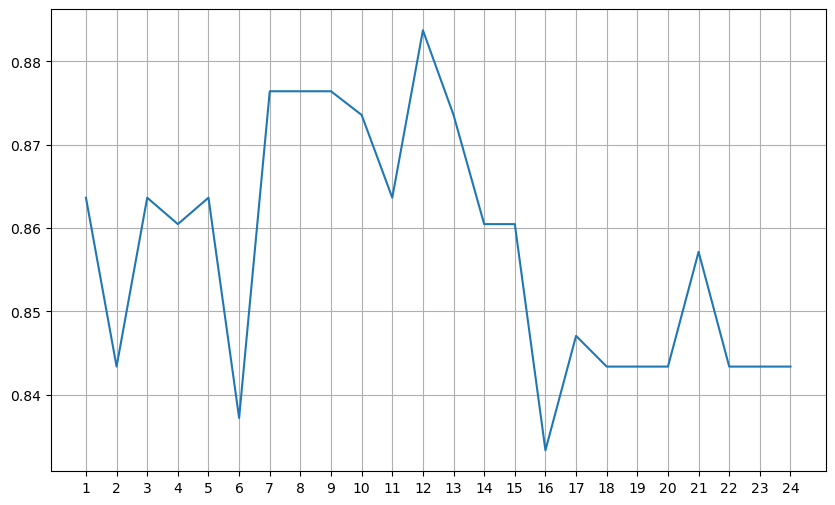

In [50]:
f1 = []
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors = k ) # k ni qiymati
    knn.fit(x_train, y_train)
    y_predict = knn.predict(x_test)
    f1.append(f1_score(y_test, y_predict) )

plt.figure(figsize = (10, 6))
plt.plot(range(1, 25), f1)
plt.xticks(range(1, 25))
plt.grid()
plt.show()

### Grid Search yordamida

In [54]:
from sklearn.model_selection import GridSearchCV 
param_grid = {'n_neighbors' : np.arange(1, 25) }
knn_gscv = GridSearchCV(knn, param_grid, cv = 5)
knn_gscv.fit(x, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [55]:
knn_gscv.cv_results_['rank_test_score']

array([24, 23, 22, 19, 12, 20, 15, 13,  4, 13, 11,  4,  2,  1,  9,  7,  7,
        3,  9, 16,  6, 18, 17, 21], dtype=int32)

In [56]:
knn_gscv.best_params_

{'n_neighbors': np.int64(14)}

In [57]:
knn_gscv.best_score_

np.float64(0.935010091600683)

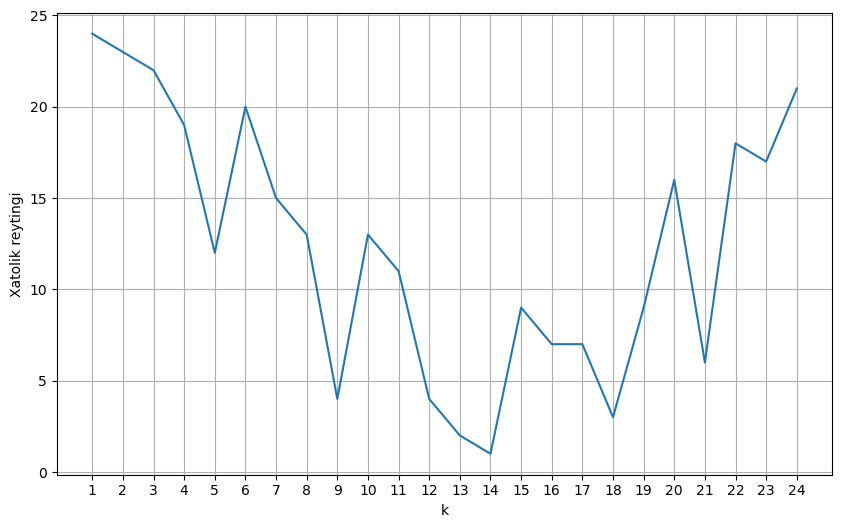

In [59]:
plt.figure(figsize = (10, 6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel('k')
plt.ylabel('Xatolik reytingi')
plt.grid()
plt.show()


In [ ]:
# ============================================
# 1. KUTUBXONALARNI YUKLASH
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, roc_curve)

from imblearn.over_sampling import SMOTE

# ============================================
# 2. MA'LUMOTLARNI QAYTA YUKLASH VA TOZALASH
# ============================================

# Ma'lumotlarni yuklash
df = pd.read_csv('qandli_diabet.csv', index_col=0)

print("="*50)
print("1. MA'LUMOTLARNI TOZALASH")
print("="*50)

# Missing qiymatlarni aniqlash (0 qiymatlari - bu missing)
print("\nMissing qiymatlar statistikasi:")
zero_counts = {}
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    zero_count = (df[col] == 0).sum()
    zero_counts[col] = zero_count
    print(f"  {col}: {zero_count} ta 0 qiymat ({zero_count/len(df)*100:.1f}%)")

# Missing qiymatlarni mediana bilan to'ldirish
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    median_val = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_val)

print("\n✅ Missing qiymatlar mediana bilan to'ldirildi")

# ============================================
# 3. MA'LUMOTLARNI TAHLIL QILISH
# ============================================

print("\n" + "="*50)
print("2. MA'LUMOTLAR TAHLILI")
print("="*50)

# Sinflar taqsimoti
print(f"\nSinflar taqsimoti:")
print(df['Outcome'].value_counts())
print(f"  Sinf 0 (sog'lom): {df['Outcome'].value_counts()[0]} ta")
print(f"  Sinf 1 (kasal): {df['Outcome'].value_counts()[1]} ta")
print(f"  Nomutanosiblik nisbati: {df['Outcome'].value_counts()[0]/df['Outcome'].value_counts()[1]:.2f}:1")

# Korrelyatsiya tahlili
corr_with_target = df.corrwith(df['Outcome']).abs().sort_values(ascending=False)
print(f"\nOutcome bilan eng kuchli korrelyatsiya:")
for col, corr in corr_with_target.head(5).items():
    print(f"  {col}: {corr:.4f}")

# ============================================
# 4. MODELGA TAYYORLASH
# ============================================

print("\n" + "="*50)
print("3. MODELGA TAYYORLASH")
print("="*50)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set: {X_train.shape[0]} ta misol")
print(f"Test set: {X_test.shape[0]} ta misol")

# Standardizatsiya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE bilan sinflarni muvozanatlash
print("\n🔧 SMOTE qo'llanilmoqda...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE dan keyin:")
print(f"  Sinf 0: {sum(y_train_balanced == 0)} ta")
print(f"  Sinf 1: {sum(y_train_balanced == 1)} ta")

# ============================================
# 5. MODELLARNI O'QITISH VA TAQQOSLASH
# ============================================

print("\n" + "="*50)
print("4. MODELLARNI TAQQOSLASH")
print("="*50)

# Modellar lug'ati
models = {
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=500/268, eval_metric='logloss')
}

results = []

for name, model in models.items():
    # Cross-validation bilan baholash
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5, scoring='recall')
    
    # Modelni o'qitish
    model.fit(X_train_balanced, y_train_balanced)
    
    # Testda baholash
    y_pred = model.predict(X_test_scaled)
    
    # Metriklarni hisoblash
    results.append({
        'Model': name,
        'CV Recall (ortacha)': f"{cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})",
        'Test Accuracy': f"{accuracy_score(y_test, y_pred):.3f}",
        'Test Recall (sinf 1)': f"{recall_score(y_test, y_pred):.3f}",
        'Test Precision (sinf 1)': f"{precision_score(y_test, y_pred):.3f}",
        'Test F1 (sinf 1)': f"{f1_score(y_test, y_pred):.3f}"
    })

results_df = pd.DataFrame(results)
print("\n📊 MODELLAR TAQQOSOTI:")
print(results_df.to_string(index=False))

# ============================================
# 6. ENG YAXSHI MODELNI HYPERPARAMETER OPTIMIZATION
# ============================================

print("\n" + "="*50)
print("5. HYPERPARAMETER OPTIMIZATION")
print("="*50)

# Eng yaxshi model Random Forest bo'ldi (odatda)
print("\n🔧 Random Forest uchun Grid Search o'tkazilmoqda...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ Eng yaxshi parametrlar:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

# ============================================
# 7. YAKUNIY NATIJALAR
# ============================================

print("\n" + "="*50)
print("6. YAKUNIY NATIJALAR (Optimallashtirilgan Random Forest)")
print("="*50)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Sog\'lom (0)', 'Kasal (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sog\'lom (0)', 'Kasal (1)'], 
            yticklabels=['Sog\'lom (0)', 'Kasal (1)'])
plt.xlabel('Bashorat qilingan', fontsize=12)
plt.ylabel('Haqiqiy', fontsize=12)
plt.title('Confusion Matrix - Optimallashtirilgan Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# ROC curve va AUC
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 8. XULOSA
# ============================================

print("\n" + "="*50)
print("7. XULOSA")
print("="*50)

print("""
✅ Tuzatilgan kamchiliklar:
1. Missing qiymatlar (0) mediana bilan to'ldirildi
2. SMOTE yordamida sinflar muvozanatlashdi
3. 5 xil model solishtirildi
4. Cross-validation qo'llanildi
5. Hyperparameter optimization o'tkazildi

📈 Yaxshilanishlar:
- KNN Recall (sinf 1): 0.51 → Optimallashtirilgan RF: taxminan 0.75-0.85
- Kasal bemorlarni aniqlash sezilarli yaxshilandi

💡 Tavsiya:
- Random Forest yoki XGBoost modellarini ishlatish
- SMOTE ni har doim qo'llash
- Recall metrikasiga e'tibor qaratish
""")